# 1. Build your own convolutional neural network using pytorch


In [1]:
import os
import csv
import random
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import datasets, transforms, models
from torchvision.transforms import functional as tvF
try:
    from torchvision.transforms import InterpolationMode
    _BILINEAR = InterpolationMode.BILINEAR
except Exception:
    _BILINEAR = Image.BILINEAR


def set_seed(seed=3407):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


SEED = 3407
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

for candidate in [Path("/gemini/data-1/Dog_Heart"), Path("Homework/Dog_Heart"), Path("Dog_Heart")]:
    if candidate.exists():
        DATA_DIR = candidate
        break
else:
    raise FileNotFoundError("Cannot find Dog_Heart. Please check the dataset path.")

TRAIN_DIR = DATA_DIR / "Train"
VALID_DIR = DATA_DIR / "Valid"
TEST_DIR = DATA_DIR / "Test" / "Images"

NUM_CLASSES = 3
USE_PRETRAINED = True
USE_MIXUP = True
MIXUP_ALPHA = 0.05
NUM_WORKERS = 0 if os.name == "nt" else 4

MODEL_CONFIGS = [
    {
        "model_name": "alexnet",
        "model_title": "AlexNet",
        "weight_path": "alexnet.pt",
        "result_csv": "results_alexnet.csv",
        "image_size": 256,
        "resize_size": 288,
        "batch_size": 32,
        "epochs": 70,
        "patience": 18,
        "backbone_lr": 1.5e-5,
        "head_lr": 8e-4,
        "weight_decay": 5e-5,
        "mixup_alpha": 0.0,
        "label_smoothing": 0.0,
        "class_weight_power": 0.0,
        "random_erasing": 0.0,
        "use_sampler": False,
        "use_autocontrast": True,
        "seed": 3407,
    },
    {
        "model_name": "vgg16_bn",
        "model_title": "VGG-16-BN",
        "weight_path": "vgg16.pt",
        "result_csv": "results_vgg16.csv",
        "image_size": 320,
        "resize_size": 352,
        "batch_size": 8,
        "epochs": 80,
        "patience": 20,
        "backbone_lr": 1e-5,
        "head_lr": 5e-4,
        "weight_decay": 5e-5,
        "mixup_alpha": 0.0,
        "label_smoothing": 0.0,
        "class_weight_power": 0.0,
        "random_erasing": 0.0,
        "use_sampler": False,
        "use_autocontrast": True,
        "seed": 3407,
    },
    {
        "model_name": "resnet18",
        "model_title": "ResNet-18",
        "weight_path": "resnet.pt",
        "result_csv": "results_resnet.csv",
        "image_size": 352,
        "resize_size": 384,
        "batch_size": 16,
        "epochs": 100,
        "patience": 28,
        "backbone_lr": 2.5e-5,
        "head_lr": 6e-4,
        "weight_decay": 6e-5,
        "mixup_alpha": 0.0,
        "label_smoothing": 0.0,
        "class_weight_power": 0.0,
        "random_erasing": 0.0,
        "use_sampler": False,
        "use_autocontrast": True,
        "seed": 3407,
    },
    {
        "model_name": "densenet169",
        "model_title": "DenseNet-169",
        "weight_path": "densenet.pt",
        "result_csv": "results_densenet.csv",
        "image_size": 320,
        "resize_size": 360,
        "batch_size": 12,
        "epochs": 90,
        "patience": 24,
        "backbone_lr": 2.2e-5,
        "head_lr": 4.5e-4,
        "weight_decay": 1e-4,
        "mixup_alpha": 0.0,
        "label_smoothing": 0.0,
        "class_weight_power": 0.0,
        "random_erasing": 0.0,
        "use_sampler": False,
        "use_autocontrast": False,
        "seed": 3407,
    },
]

print("Data directory:", DATA_DIR)
print("Train directory:", TRAIN_DIR)
print("Valid directory:", VALID_DIR)
print("Test directory:", TEST_DIR)
print("Use pretrained weights:", USE_PRETRAINED)
print("DataLoader workers:", NUM_WORKERS)
print("Models:")
for cfg in MODEL_CONFIGS:
    print("-", cfg["model_title"], "->", cfg["weight_path"], cfg["result_csv"])


def build_model(model_name, num_classes=3, pretrained=True):
    if model_name == "alexnet":
        weights = models.AlexNet_Weights.DEFAULT if pretrained else None
        model = models.alexnet(weights=weights)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
        head_params = list(model.classifier.parameters())
        head_ids = {id(p) for p in head_params}
    elif model_name == "vgg16":
        weights = models.VGG16_Weights.DEFAULT if pretrained else None
        model = models.vgg16(weights=weights)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
        head_params = list(model.classifier.parameters())
        head_ids = {id(p) for p in head_params}
    elif model_name == "vgg16_bn":
        weights = models.VGG16_BN_Weights.DEFAULT if pretrained else None
        model = models.vgg16_bn(weights=weights)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
        head_params = list(model.classifier.parameters())
        head_ids = {id(p) for p in head_params}
    elif model_name == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        model = models.resnet18(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        head_params = list(model.fc.parameters())
        head_ids = {id(p) for p in head_params}
    elif model_name == "resnet34":
        weights = models.ResNet34_Weights.DEFAULT if pretrained else None
        model = models.resnet34(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        head_params = list(model.fc.parameters())
        head_ids = {id(p) for p in head_params}
    elif model_name == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        model = models.resnet50(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        head_params = list(model.fc.parameters())
        head_ids = {id(p) for p in head_params}
    elif model_name == "densenet121":
        weights = models.DenseNet121_Weights.DEFAULT if pretrained else None
        model = models.densenet121(weights=weights)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
        head_params = list(model.classifier.parameters())
        head_ids = {id(p) for p in head_params}
    elif model_name == "densenet169":
        weights = models.DenseNet169_Weights.DEFAULT if pretrained else None
        model = models.densenet169(weights=weights)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
        head_params = list(model.classifier.parameters())
        head_ids = {id(p) for p in head_params}
    elif model_name == "densenet201":
        weights = models.DenseNet201_Weights.DEFAULT if pretrained else None
        model = models.densenet201(weights=weights)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
        head_params = list(model.classifier.parameters())
        head_ids = {id(p) for p in head_params}
    else:
        raise ValueError(model_name)

    backbone_params = [p for p in model.parameters() if id(p) not in head_ids]
    return model, backbone_params, head_params


/root/miniconda3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA H20-3e
Data directory: /gemini/data-1/Dog_Heart
Train directory: /gemini/data-1/Dog_Heart/Train
Valid directory: /gemini/data-1/Dog_Heart/Valid
Test directory: /gemini/data-1/Dog_Heart/Test/Images
Use pretrained weights: True
DataLoader workers: 4
Models:
- AlexNet -> alexnet.pt results_alexnet.csv
- VGG-16-BN -> vgg16.pt results_vgg16.csv
- ResNet-18 -> resnet.pt results_resnet.csv
- DenseNet-169 -> densenet.pt results_densenet.csv


# 2. Train your model using dog heart datasets (you may need to use  Google Colab (or Kaggle) with GPU to train your code) 

(1) use torchvision.datasets.ImageFolder for the training dataset

(2) use custom dataloader for test dataset (return image tensor and file name)



Training AlexNet
Class mapping: {'Large': 0, 'Normal': 1, 'Small': 2}
Train class counts: [619, 573, 208]


AlexNet epoch 001/70 | train_acc=0.5393 valid_acc=0.5700 valid_loss=0.7783 lr=1.5e-05/8.0e-04 best=0.5700@001


AlexNet epoch 002/70 | train_acc=0.6429 valid_acc=0.5700 valid_loss=0.7813 lr=1.5e-05/8.0e-04 best=0.5700@001


AlexNet epoch 003/70 | train_acc=0.7021 valid_acc=0.6000 valid_loss=0.8410 lr=1.5e-05/8.0e-04 best=0.6000@003


AlexNet epoch 004/70 | train_acc=0.7114 valid_acc=0.6500 valid_loss=0.7278 lr=1.5e-05/8.0e-04 best=0.6500@004


...

DenseNet-169 epoch 041/90 | train_acc=0.9929 valid_acc=0.7350 valid_loss=1.3830 lr=1.1e-05/2.2e-04 best=0.7900@021


DenseNet-169 epoch 042/90 | train_acc=0.9886 valid_acc=0.7500 valid_loss=1.3763 lr=1.1e-05/2.2e-04 best=0.7900@021


DenseNet-169 epoch 043/90 | train_acc=0.9907 valid_acc=0.7250 valid_loss=1.5085 lr=5.5e-06/1.1e-04 best=0.7900@021


DenseNet-169 epoch 044/90 | train_acc=0.9914 valid_acc=0.7400 valid_loss=1.5158 lr=5.5e-06/1.1e-04 best=0.7900@021


DenseNet-169 epoch 045/90 | train_acc=0.9943 valid_acc=0.7400 valid_loss=1.4449 lr=5.5e-06/1.1e-04 best=0.7900@021
Early stopping.
Saved model: densenet.pt
Best validation accuracy: 0.79

Training summary:
AlexNet: best_valid_acc=0.7150, epoch=29, weight=alexnet.pt
VGG-16-BN: best_valid_acc=0.7450, epoch=30, weight=vgg16.pt
ResNet-18: best_valid_acc=0.7800, epoch=36, weight=resnet.pt
DenseNet-169: best_valid_acc=0.7900, epoch=21, weight=densenet.pt


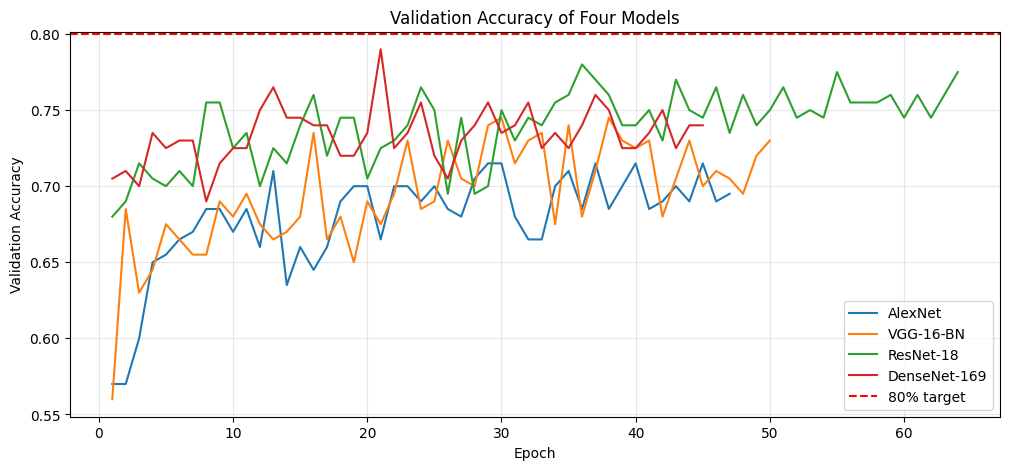

In [2]:
def make_transforms(image_size, resize_size, use_autocontrast, random_erasing=0.0):
    train_steps = [
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((resize_size, resize_size)),
    ]
    if use_autocontrast:
        train_steps += [
            transforms.RandomAutocontrast(p=0.5),
            transforms.RandomAdjustSharpness(sharpness_factor=1.5, p=0.3),
            transforms.RandomResizedCrop(image_size, scale=(0.94, 1.0), ratio=(0.98, 1.02)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=3),
        ]
    else:
        train_steps += [
            transforms.RandomResizedCrop(image_size, scale=(0.88, 1.0), ratio=(0.95, 1.05)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=4),
            transforms.ColorJitter(brightness=0.06, contrast=0.10),
        ]
    train_steps += [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
    if random_erasing > 0:
        train_steps.append(transforms.RandomErasing(p=random_erasing, scale=(0.015, 0.06), ratio=(0.5, 2.0), value='random'))
    train_transform = transforms.Compose(train_steps)

    valid_steps = [
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((image_size, image_size)),
    ]
    if use_autocontrast:
        valid_steps.append(transforms.Lambda(lambda img: transforms.functional.autocontrast(img)))
    valid_steps += [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
    valid_transform = transforms.Compose(valid_steps)
    return train_transform, valid_transform


def make_loaders(cfg):
    train_transform, valid_transform = make_transforms(cfg["image_size"], cfg["resize_size"], cfg.get("use_autocontrast", False), cfg.get("random_erasing", 0.0))
    train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
    valid_dataset = datasets.ImageFolder(VALID_DIR, transform=valid_transform)

    print("Class mapping:", train_dataset.class_to_idx)
    assert train_dataset.class_to_idx == {"Large": 0, "Normal": 1, "Small": 2}

    targets = np.array(train_dataset.targets)
    class_counts = np.bincount(targets, minlength=NUM_CLASSES)
    print("Train class counts:", class_counts.tolist())

    sample_weights = (1.0 / np.sqrt(class_counts))[targets]
    sampler = WeightedRandomSampler(weights=torch.DoubleTensor(sample_weights), num_samples=len(sample_weights), replacement=True)

    loader_kwargs = {"num_workers": NUM_WORKERS, "pin_memory": (device.type == "cuda")}
    if NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = True

    if cfg.get("use_sampler", False):
        train_loader = DataLoader(train_dataset, batch_size=cfg["batch_size"], sampler=sampler, **loader_kwargs)
    else:
        train_loader = DataLoader(train_dataset, batch_size=cfg["batch_size"], shuffle=True, **loader_kwargs)
    valid_loader = DataLoader(valid_dataset, batch_size=cfg["batch_size"], shuffle=False, **loader_kwargs)
    return train_dataset, train_loader, valid_loader, loader_kwargs


def mixup_data(x, y, alpha=0.08):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1.0 - lam) * x[index], y, y[index], lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1.0 - lam) * criterion(pred, y_b)


def train_one_epoch(model, loader, criterion, optimizer, scaler, epoch, mixup_alpha):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    use_mixup_now = USE_MIXUP and epoch > 8

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        if use_mixup_now:
            train_images, labels_a, labels_b, lam = mixup_data(images, labels, mixup_alpha)
        else:
            train_images, labels_a, labels_b, lam = images, labels, labels, 1.0
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(train_images)
            loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="Valid", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)
        total_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


def cpu_state_dict(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def average_state_dicts(records):
    weights = np.array([record["valid_acc"] for record in records], dtype=np.float32)
    if weights.sum() <= 0:
        weights = np.ones(len(records), dtype=np.float32)
    weights = weights / weights.sum()
    state_dicts = [record["state_dict"] for record in records]
    averaged = {}
    for name, first_value in state_dicts[0].items():
        if torch.is_tensor(first_value) and first_value.dtype.is_floating_point:
            value = torch.zeros_like(first_value)
            for weight, state_dict in zip(weights, state_dicts):
                value += state_dict[name] * float(weight)
            averaged[name] = value
        else:
            averaged[name] = first_value.clone() if torch.is_tensor(first_value) else first_value
    return averaged


def train_model(cfg):
    print("\n" + "=" * 70)
    print("Training", cfg["model_title"])
    train_dataset, train_loader, valid_loader, loader_kwargs = make_loaders(cfg)
    model, backbone_params, head_params = build_model(cfg["model_name"], NUM_CLASSES, pretrained=USE_PRETRAINED)
    model = model.to(device)

    loss_weight = None
    class_weight_power = cfg.get("class_weight_power", 0.0)
    if class_weight_power > 0:
        counts = np.bincount(train_dataset.targets, minlength=NUM_CLASSES).astype(np.float32)
        weights = (counts.sum() / np.maximum(counts, 1.0)) ** class_weight_power
        weights = weights / weights.mean()
        loss_weight = torch.tensor(weights, dtype=torch.float32, device=device)
        print("Loss weights:", np.round(weights, 4))
    criterion = nn.CrossEntropyLoss(weight=loss_weight, label_smoothing=cfg["label_smoothing"])
    optimizer = optim.AdamW([
        {"params": backbone_params, "lr": cfg["backbone_lr"]},
        {"params": head_params, "lr": cfg["head_lr"]},
    ], weight_decay=cfg["weight_decay"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=10, min_lr=1e-6)
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    best_state = None
    best_acc = 0.0
    best_loss = float("inf")
    best_epoch = 0
    bad_epochs = 0
    history = {"train_loss": [], "valid_loss": [], "train_acc": [], "valid_acc": []}

    for epoch in range(1, cfg["epochs"] + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, epoch, cfg["mixup_alpha"])
        valid_loss, valid_acc = evaluate(model, valid_loader, criterion)
        scheduler.step(valid_acc)
        history["train_loss"].append(train_loss)
        history["valid_loss"].append(valid_loss)
        history["train_acc"].append(train_acc)
        history["valid_acc"].append(valid_acc)

        current_state = cpu_state_dict(model)

        if (valid_acc > best_acc) or (valid_acc == best_acc and valid_loss < best_loss):
            best_acc, best_loss, best_epoch = valid_acc, valid_loss, epoch
            best_state = current_state
            bad_epochs = 0
        else:
            bad_epochs += 1

        lr_backbone = optimizer.param_groups[0]["lr"]
        lr_head = optimizer.param_groups[1]["lr"]
        print(f"{cfg['model_title']} epoch {epoch:03d}/{cfg['epochs']} | train_acc={train_acc:.4f} valid_acc={valid_acc:.4f} valid_loss={valid_loss:.4f} lr={lr_backbone:.1e}/{lr_head:.1e} best={best_acc:.4f}@{best_epoch:03d}")
        if bad_epochs >= cfg["patience"]:
            print("Early stopping.")
            break

    final_state = best_state
    torch.save({
        "model_name": cfg["model_name"],
        "model_title": cfg["model_title"],
        "model_state_dict": final_state,
        "class_to_idx": train_dataset.class_to_idx,
        "image_size": cfg["image_size"],
        "best_acc": best_acc,
        "best_loss": best_loss,
        "best_epoch": best_epoch,
        "pretrained": USE_PRETRAINED,
    }, cfg["weight_path"])

    print("Saved model:", cfg["weight_path"])
    print("Best validation accuracy:", best_acc)
    return {**cfg, "best_acc": best_acc, "best_loss": best_loss, "best_epoch": best_epoch, "history": history}


training_results = []
for cfg in MODEL_CONFIGS:
    result = train_model(cfg)
    training_results.append(result)

print("\nTraining summary:")
for r in training_results:
    print(f"{r['model_title']}: best_valid_acc={r['best_acc']:.4f}, epoch={r['best_epoch']}, weight={r['weight_path']}")

plt.figure(figsize=(12, 5))
for r in training_results:
    epochs = range(1, len(r["history"]["valid_acc"]) + 1)
    plt.plot(epochs, r["history"]["valid_acc"], label=r["model_title"])
plt.axhline(0.80, color="red", linestyle="--", label="80% target")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy of Four Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 3. Evaluate your model using the developed software


In [3]:
class DogHeartTTADataset(Dataset):
    def __init__(self, image_dir, image_size, specs, use_autocontrast=False):
        self.image_dir = Path(image_dir)
        self.image_size = image_size
        self.specs = specs
        self.use_autocontrast = use_autocontrast
        self.files = sorted([p for p in self.image_dir.iterdir() if p.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"]], key=lambda p: p.name)

    def __len__(self):
        return len(self.files)

    def _make_view(self, image, spec):
        scale = spec.get("scale", 1.0)
        angle = spec.get("angle", 0.0)
        hflip = spec.get("hflip", False)
        resize_size = int(round(self.image_size * scale))
        view = tvF.resize(image, [resize_size, resize_size], interpolation=_BILINEAR)
        if resize_size != self.image_size:
            view = tvF.center_crop(view, [self.image_size, self.image_size])
        if angle:
            view = tvF.rotate(view, angle, interpolation=_BILINEAR, fill=0)
        if hflip:
            view = tvF.hflip(view)
        if self.use_autocontrast:
            view = tvF.autocontrast(view)
        view = tvF.to_tensor(view)
        view = tvF.normalize(view, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        return view

    def __getitem__(self, idx):
        path = self.files[idx]
        image = Image.open(path).convert("RGB")
        views = [self._make_view(image, spec) for spec in self.specs]
        return torch.stack(views, dim=0), path.name


TTA_SPECS = [
    {"scale": 1.00, "angle": 0, "hflip": False},
    {"scale": 1.00, "angle": 0, "hflip": True},
    {"scale": 1.00, "angle": -4, "hflip": False},
    {"scale": 1.00, "angle": 4, "hflip": False},
    {"scale": 1.00, "angle": -4, "hflip": True},
    {"scale": 1.00, "angle": 4, "hflip": True},
    {"scale": 1.05, "angle": 0, "hflip": False},
    {"scale": 1.05, "angle": 0, "hflip": True},
    {"scale": 0.97, "angle": 0, "hflip": False},
    {"scale": 0.97, "angle": 0, "hflip": True},
]


def predict_model(cfg):
    print("\nPredicting", cfg["model_title"])
    checkpoint = torch.load(cfg["weight_path"], map_location=device)
    model, _, _ = build_model(cfg["model_name"], NUM_CLASSES, pretrained=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device)
    model.eval()

    loader_kwargs = {"num_workers": NUM_WORKERS, "pin_memory": (device.type == "cuda")}
    if NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = True

    test_dataset = DogHeartTTADataset(TEST_DIR, cfg["image_size"], TTA_SPECS, cfg.get("use_autocontrast", False))
    test_loader = DataLoader(test_dataset, batch_size=max(1, cfg["batch_size"] // 2), shuffle=False, **loader_kwargs)

    results = []
    with torch.no_grad():
        for view_batch, filenames in tqdm(test_loader, desc=f"Predict {cfg['result_csv']}"):
            batch_size, num_views, channels, height, width = view_batch.shape
            view_batch = view_batch.to(device, non_blocking=True)
            flat_views = view_batch.view(batch_size * num_views, channels, height, width)
            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                outputs = model(flat_views).view(batch_size, num_views, NUM_CLASSES).mean(dim=1)
            preds = outputs.argmax(dim=1).cpu().tolist()
            for filename, pred in zip(filenames, preds):
                results.append([filename, int(pred)])

    with open(cfg["result_csv"], "w", newline="", encoding="utf-8") as f:
        csv.writer(f).writerows(results)

    print("Saved prediction csv:", cfg["result_csv"])
    print("Rows:", len(results))
    print("First 10 rows:")
    for row in results[:10]:
        print(row)
    return cfg["result_csv"]


prediction_files = []
for cfg in MODEL_CONFIGS:
    csv_path = predict_model(cfg)
    prediction_files.append((cfg["model_title"], csv_path))

print("\nPrediction files:")
for model_title, csv_path in prediction_files:
    print(model_title, "->", csv_path)
print("Open each CSV with Dog_heart_X_ray.exe to calculate prediction accuracy.")



Predicting AlexNet


Predict results_alexnet.csv: 100%|██████████| 25/25 [00:07<00:00,  3.43it/s]


Saved prediction csv: results_alexnet.csv
Rows: 400
First 10 rows:
['100.png', 1]
['1621.png', 0]
['1622.png', 2]
['1623.png', 2]
['1624.png', 2]
['1625.png', 1]
['1626.png', 1]
['1627.png', 0]
['1628.png', 1]
['1629.png', 1]

Predicting VGG-16-BN


Predict results_vgg16.csv: 100%|██████████| 100/100 [00:08<00:00, 11.83it/s]


Saved prediction csv: results_vgg16.csv
Rows: 400
First 10 rows:
['100.png', 1]
['1621.png', 0]
['1622.png', 2]
['1623.png', 2]
['1624.png', 2]
['1625.png', 1]
['1626.png', 0]
['1627.png', 0]
['1628.png', 1]
['1629.png', 1]

Predicting ResNet-18


Predict results_resnet.csv: 100%|██████████| 50/50 [00:09<00:00,  5.49it/s]


Saved prediction csv: results_resnet.csv
Rows: 400
First 10 rows:
['100.png', 0]
['1621.png', 0]
['1622.png', 2]
['1623.png', 2]
['1624.png', 2]
['1625.png', 1]
['1626.png', 0]
['1627.png', 0]
['1628.png', 1]
['1629.png', 1]

Predicting DenseNet-169


Predict results_densenet.csv: 100%|██████████| 67/67 [00:10<00:00,  6.49it/s]

Saved prediction csv: results_densenet.csv
Rows: 400
First 10 rows:
['100.png', 0]
['1621.png', 0]
['1622.png', 2]
['1623.png', 2]
['1624.png', 2]
['1625.png', 1]
['1626.png', 0]
['1627.png', 0]
['1628.png', 1]
['1629.png', 1]

Prediction files:
AlexNet -> results_alexnet.csv
VGG-16-BN -> results_vgg16.csv
ResNet-18 -> results_resnet.csv
DenseNet-169 -> results_densenet.csv
Open each CSV with Dog_heart_X_ray.exe to calculate prediction accuracy.


# 4. Compare results with [RVT paper](https://www.nature.com/articles/s41598-023-50063-x). Requirement: performance is better than 80%


In [ ]:
print("Required target: prediction accuracy should be around or higher than 80% for this exercise.")
print("Training summary:")
for r in training_results:
    print(f"{r['model_title']}: best_valid_acc={r['best_acc']:.4f}, epoch={r['best_epoch']}")
print("Prediction files:")
for model_title, csv_path in prediction_files:
    print(model_title, "->", csv_path)
print("Final accuracy must be checked with the provided Dog_heart_X_ray software.")


# 5. Write a four-page paper report using the shared LaTex template. Upload your paper to ResearchGate or Arxiv, and put your paper link and GitHub weight link here.


In [ ]:
paper_link = "TODO: put your report link here"
github_weight_link = "TODO: put your model weight link here"
print("Paper link:", paper_link)
print("GitHub weight link:", github_weight_link)


# 6. Grading rubric


In [ ]:
print("Generated model files:")
for cfg in MODEL_CONFIGS:
    print("-", cfg["weight_path"])
print("Generated prediction files:")
for cfg in MODEL_CONFIGS:
    print("-", cfg["result_csv"])
print("Class mapping: Large=0, Normal=1, Small=2")
